In [2]:
import os                  # Used for file and folder path operations
import tarfile             # Used to extract .tgz compressed files
import pandas as pd        # Used for data analysis and CSV file handling
from six.moves import urllib   # Used to download files from URL

# Base URL where dataset is stored (GitHub repository)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"

# Local folder path where dataset will be stored
HOUSING_PATH = os.path.join("datasets", "housing")

# Full URL of the housing dataset compressed file
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"


# Function to download and extract the housing dataset
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    
    # Create the directory datasets/housing if it does not already exist
    os.makedirs(housing_path, exist_ok=True)
    
    # Create full path for the downloaded tgz file
    tgz_path = os.path.join(housing_path, "housing.tgz")
    
    # Download the file from the internet and save it to tgz_path
    urllib.request.urlretrieve(housing_url, tgz_path)
    
    # Open the compressed tgz file
    with tarfile.open(tgz_path) as housing_tgz:
        
        # Extract all files from the tgz file into the housing_path directory
        housing_tgz.extractall(path=housing_path)


# Function to load housing CSV data into pandas DataFrame
def load_housing_data(housing_path=HOUSING_PATH):
    
    # Create full path to housing.csv file
    csv_path = os.path.join(housing_path, "housing.csv")
    
    # Read CSV file and return it as a pandas DataFrame
    return pd.read_csv(csv_path)


# Call function to download and extract dataset
fetch_housing_data()

# Load dataset into a variable named housing
housing = load_housing_data()

# Print first 5 rows of dataset
# print(housing.head())

C:\Users\tanma\AppData\Local\Temp\ipykernel_24272\2840948792.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [3]:

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<p>The hist() method relies on Matplotlib, which in turn relies on a user-specified graphical backend to draw on your screen. So
before you can plot anything, you need to specify which backend Matplotlib should use. The simplest option is to use Jupyter’s
magic comand %matplotlib inline. This tels Jupyter to set up Matplotlib so it uses Jupyter’s own backend. Plots are then
rendered within the notebook itself. Note that caling show() is optional in a Jupyter notebook, as Jupyter will automaticaly
display plots when a cell is executed.
</p>

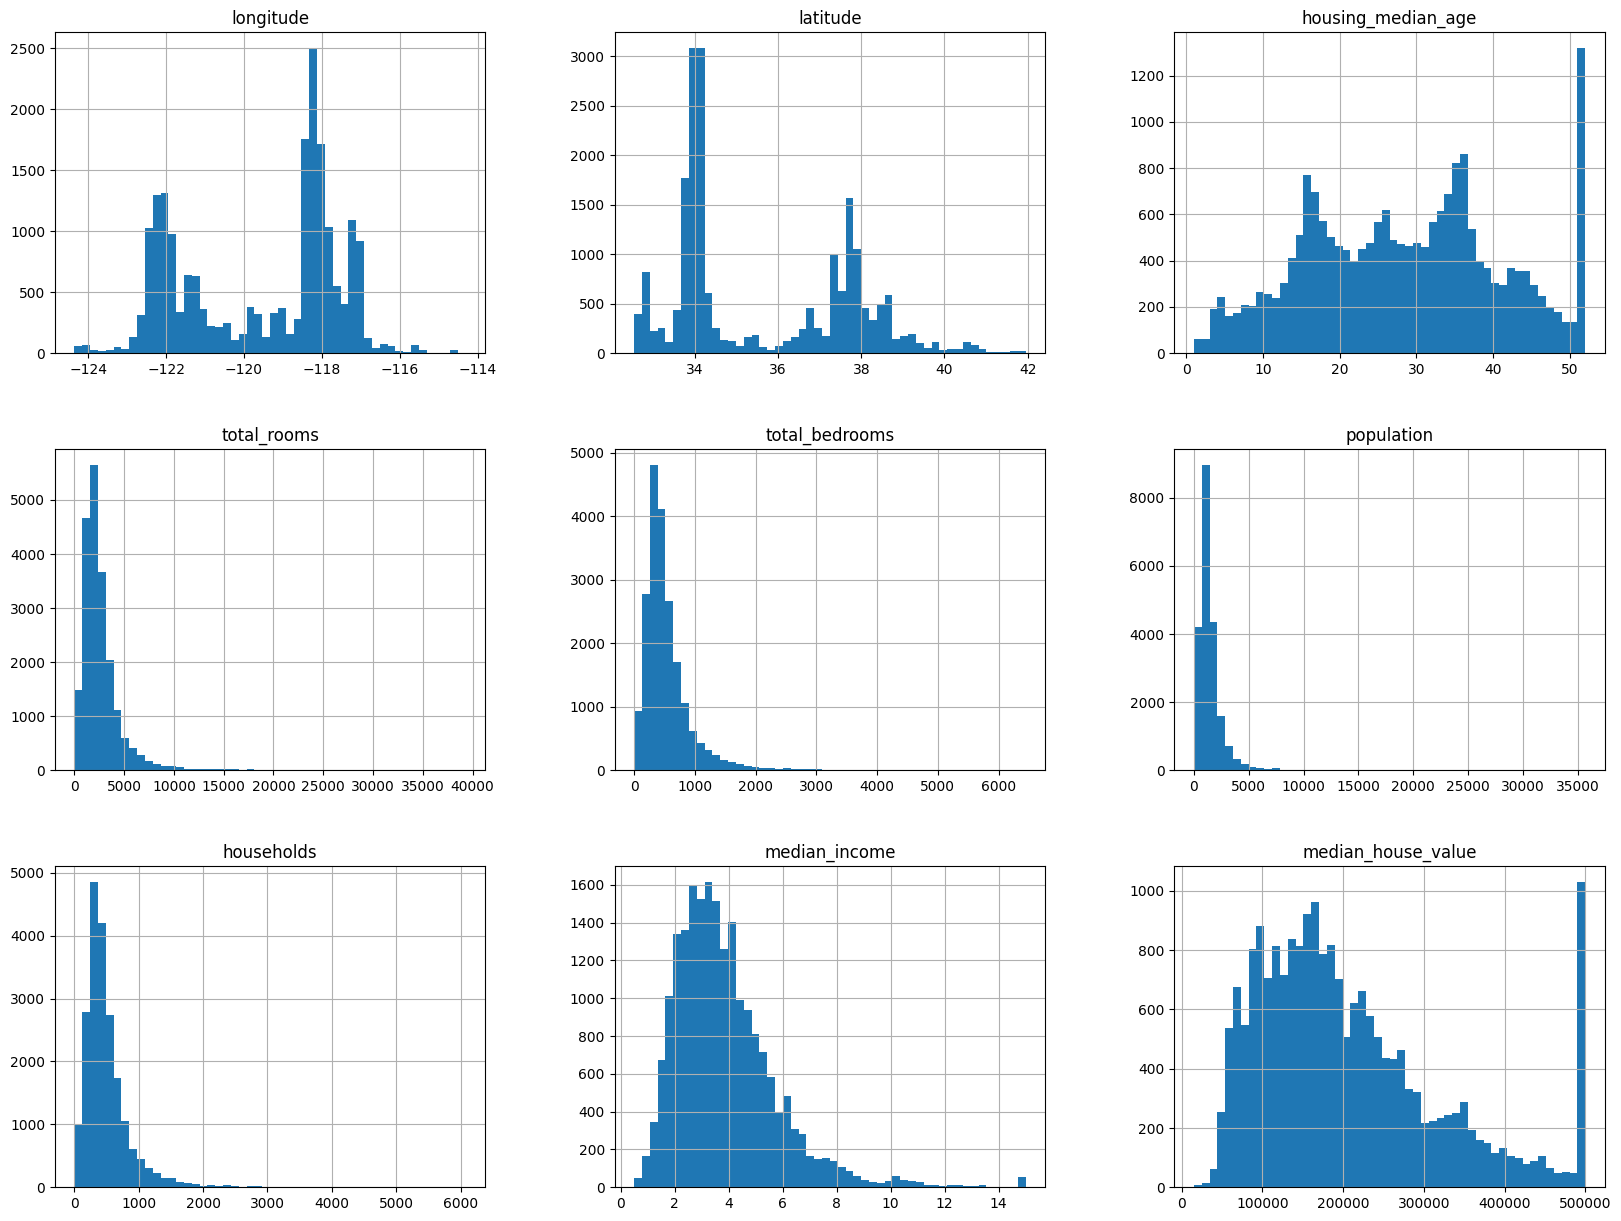

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt 
housing.hist(bins=50,figsize=(20,15))
plt.show()

# create a Test set


In [7]:
import numpy as np
def split_train_test(data,test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size =int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [8]:
train_set,test_set=split_train_test(housing,0.2)
print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}\n")

Rows in train set: 16512
Rows in test set: 4128



### How to have consistent set 

In [9]:
import hashlib 
def test_set_check(identifier,test_ratio,hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio
def split_train_test_by_id(data,test_ratio,id_column,hash=hashlib.md5):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_: test_set_check(id_,test_ratio,hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [10]:
# the housing dataset does not have a identifier column. The simplest solution is to use the row index as ID:
housing_with_id = housing.reset_index()   # adds an `index` column
train_set,test_set=split_train_test_by_id(housing_with_id,0.2,"index") 

<p>if you use the row index as a unique identifier , you need to make sure that the new data gets appended to the end of the dataset,and no row ever gets deleted.
if not possible we can use longitude and latitude as the id</p>

In [11]:
housing_with_id["id"]=housing["longitude"]*1000 +housing["latitude"]    # create ID column for housing_with_id with the help of longitude and latitude
train_set,test_set=split_train_test_by_id(housing_with_id,0.2,"id")


## splitting the data into train set and the test set using sklearn


In [12]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,random_state=42)

## Stratified sampling based on income category


In [13]:
housing["income_cat"]= np.ceil(housing["median_income"]/1.5)
housing["income_cat"].where(housing["income_cat"]<5,5.0,inplace=True)

C:\Users\tanma\AppData\Local\Temp\ipykernel_24272\109716452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["income_cat"].where(housing["income_cat"]<5,5.0,inplace=True)


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) 
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [15]:
housing["income_cat"].value_counts()/len(housing)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [16]:
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3.0


In [17]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [18]:
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3.0


# Discover and visualize the Data to Gain Insights 


In [19]:
# <!-- creating a copy of the training set  -->
housing = strat_train_set.copy()

In [20]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


# Visualizing Geographical Data

<Axes: xlabel='longitude', ylabel='latitude'>

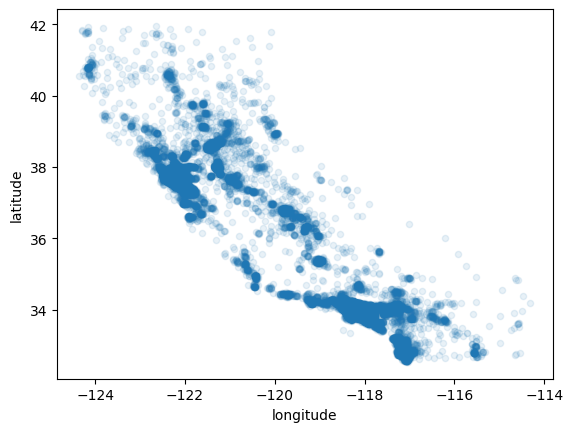

In [21]:
housing.plot(kind="scatter", x="longitude", y="latitude",alpha=0.1)

<p>We will use a predefined color map
(option cmap) called jet, which ranges from blue (low values) to red (high prices):
1</p>

<!-- using predefined color mao(option cmap) called jet, which ranges from blue(low values)to red (high prices) -->

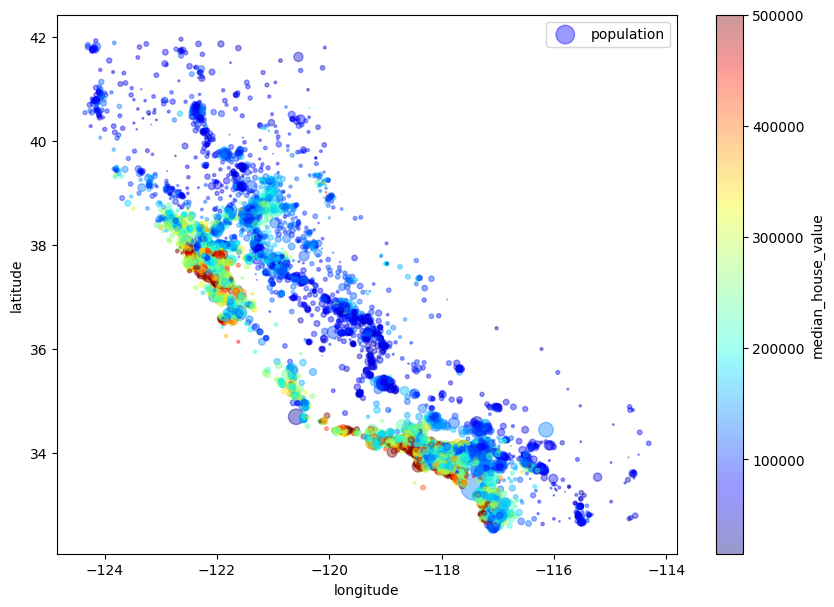

In [22]:
# Scatter plot of housing data (geographical visualization)

housing.plot(
    kind="scatter",                  # Type of plot -> scatter plot
    x="longitude",                   # X-axis represents longitude (east-west location)
    y="latitude",                    # Y-axis represents latitude (north-south location)
    
    alpha=0.4,                       # Transparency of points (0 = invisible, 1 = solid)
                                     # Helps visualize dense areas where many points overlap
    
    s=housing["population"]/100,     # Size of each dot based on population
                                     # Larger population -> bigger circle
                                     # Dividing by 100 to scale sizes properly
    
    label="population",              # Label used in legend
    
    figsize=(10,7),                  # Size of the plot (width=10, height=7)
    
    c="median_house_value",          # Color of each point based on median house value
                                     # Adds another dimension to visualization
    
    cmap=plt.get_cmap("jet"),        # Color map used (jet: blue->green->yellow->red)
                                     # Blue = low house value, Red = high house value
    
    colorbar=True                    # Shows color scale bar on the side
)

plt.legend()                         # Displays legend (population size indicator)

# Looking for correlations

In [23]:
corr_matrix= housing.corr(numeric_only=True)

In [24]:
corr_matrix.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.022159,-0.049045,-0.043567,0.409255,0.389228,0.367294,0.395286,0.187206,0.203532
std,0.485800,0.485437,0.424458,0.515528,0.541775,0.526583,0.539044,0.389784,0.380859
min,-0.924478,-0.924478,-0.364535,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,-0.142673
25%,-0.047466,-0.115290,-0.306473,0.048909,-0.009643,-0.026882,0.010869,-0.019615,-0.026882
50%,0.048909,-0.075146,-0.111315,0.200133,0.076686,0.108071,0.064590,0.002421,0.064590
75%,0.076686,-0.039245,0.005737,0.918396,0.929391,0.876324,0.918396,0.200133,0.135140
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
corr_matrix["median_house_value"].sort_values(ascending=False)
# the correlation coefficient ranges from -1 to 1. when it is close to 1 , it means 
# that there is a strong positive correlation between the two variables, meaning that as one variable 
# increases, the other variable also tends to increase. When it is close to -1, it means that there is a 
# strong negative correlation between the two variables, meaning that as one variable increases, the other 
# variable tends to decrease. When it is close to 0, it means that there is little to no correlation between 
# the two variables, meaning that changes in one variable do not predict changes in the other variable.

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

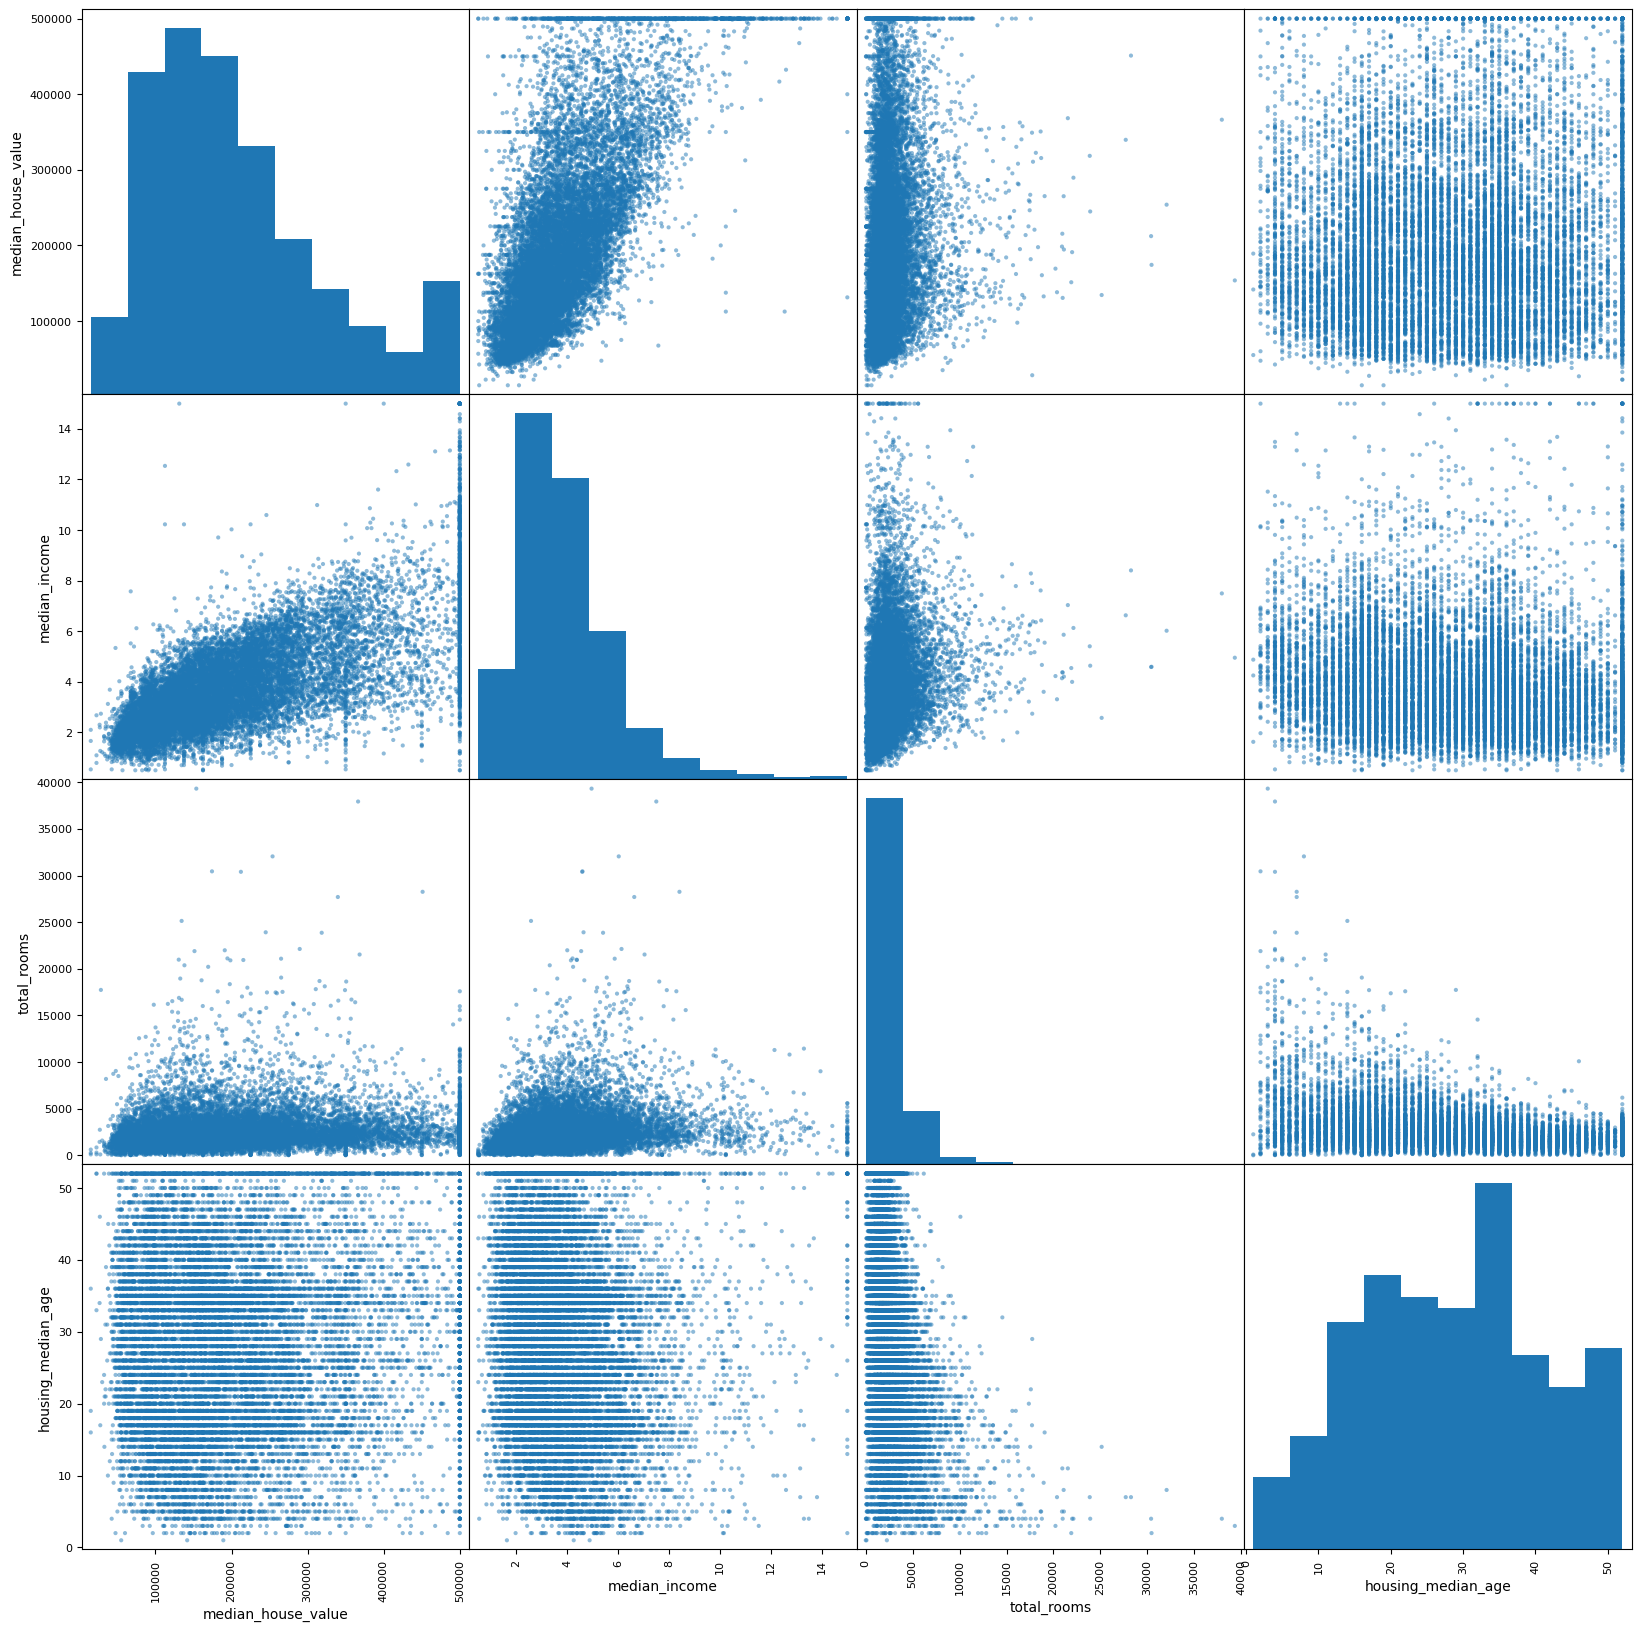

In [26]:
# Another way to check the correlation between the variables is to use the scatter_matrix function from pandas.plotting module. This function creates a matrix of scatter plots for each pair of numerical attributes in the dataset, along with histograms on the diagonal. It allows us to visually inspect the relationships between different attributes and identify any potential correlations or patterns in the data.
from pandas.plotting import scatter_matrix
attributes=["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(20,20))

<Axes: xlabel='median_income', ylabel='median_house_value'>

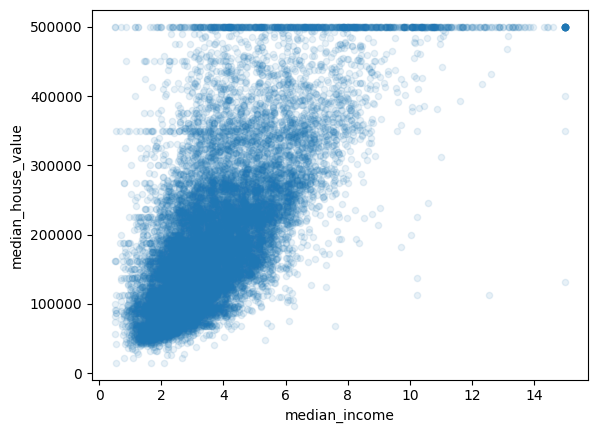

In [27]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",alpha=0.1)

# Experimenting with Attribute Combinations

In [28]:
housing["rooms_per_household"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"]=housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [29]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

# prepare the Data for Machine Learning Algorithms


In [30]:
housing =strat_train_set.drop("median_house_value",axis=1)   # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()  # labels for training set

# Data Cleaning

In [34]:
housing.dropna(subset=["total_bedrooms"])
housing.drop("total_bedrooms",axis=1)
median = housing["total_bedrooms"].median()
# housing["total_bedrooms"]=housing["total_bedrooms"].fillna(median, inplace=True)
housing.fillna({"total_bedrooms": median}, inplace=True)


e:\WORK\AI-ML\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
